In [1]:
# Task 0: Import libraries and load the official course dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

%matplotlib inline
sns.set_theme(style="whitegrid")

DATA_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

df = pd.read_csv(DATA_URL)

# Keep the course column naming compatible across versions of the dataset.
if "Unemployment_Rate" not in df.columns and "unemployment_rate" in df.columns:
    df["Unemployment_Rate"] = df["unemployment_rate"]

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

if "Year" not in df.columns:
    df["Year"] = df["Date"].dt.year

if "Month" not in df.columns:
    df["Month"] = df["Date"].dt.month_name().str[:3]

print("Data downloaded and read into a dataframe!")
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Data downloaded and read into a dataframe!
Dataset shape: (528, 16)
Columns: ['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence', 'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition', 'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales', 'Vehicle_Type', 'City', 'Unemployment_Rate']


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City,Unemployment_Rate
0,1980-01-31,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia,5.4
1,1980-02-29,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York,4.8
2,1980-03-31,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York,3.4
3,1980-04-30,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois,4.2
4,1980-05-31,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California,5.3


## Task 1.1 — Line chart showing how average annual automobile sales fluctuate from year to year

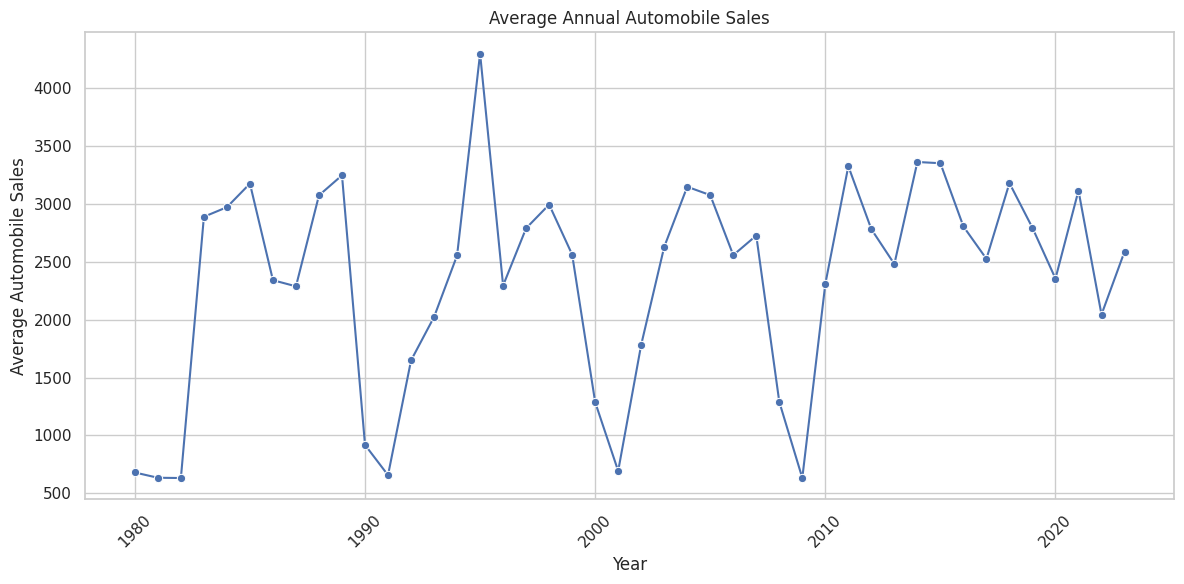

In [2]:
# TASK 1.1
yearly_sales = df.groupby("Year")["Automobile_Sales"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=yearly_sales,
    x="Year",
    y="Automobile_Sales",
    marker="o"
)
plt.xlabel("Year")
plt.ylabel("Average Automobile Sales")
plt.title("Average Annual Automobile Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Task 1.2 — Advertising expenditure and automobile sales during non-recession periods

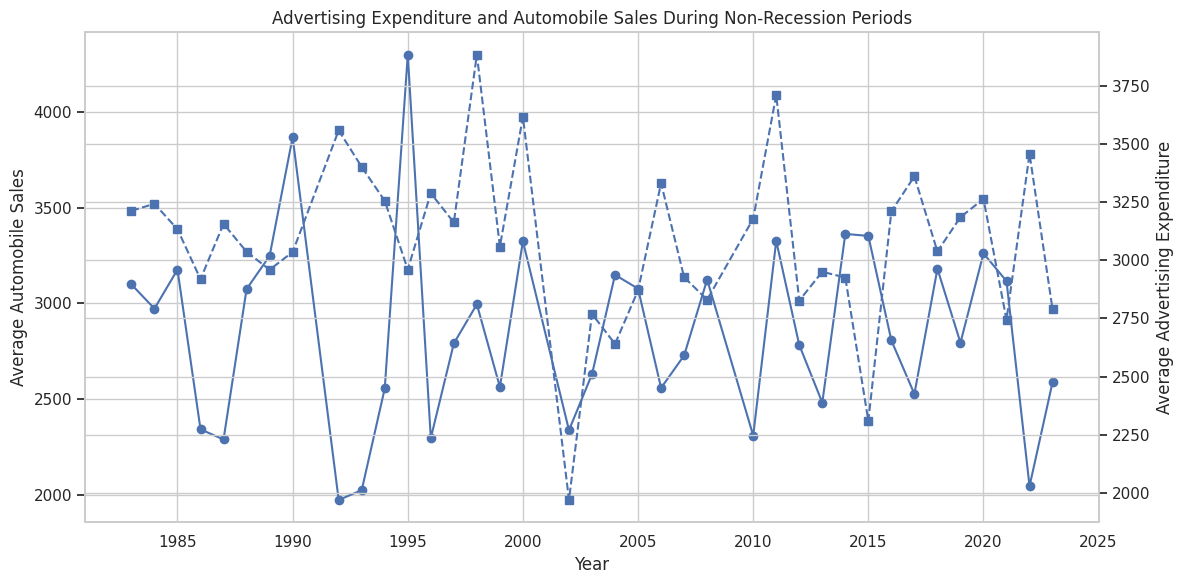

In [3]:
# TASK 1.2
non_recession_data = df[df["Recession"] == 0].copy()

non_recession_trend = (
    non_recession_data.groupby("Year", as_index=False)
    .agg(
        Automobile_Sales=("Automobile_Sales", "mean"),
        Advertising_Expenditure=("Advertising_Expenditure", "mean")
    )
)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    non_recession_trend["Year"],
    non_recession_trend["Automobile_Sales"],
    marker="o",
    label="Average Automobile Sales"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Average Automobile Sales")

ax2 = ax1.twinx()
ax2.plot(
    non_recession_trend["Year"],
    non_recession_trend["Advertising_Expenditure"],
    marker="s",
    linestyle="--",
    label="Average Advertising Expenditure"
)
ax2.set_ylabel("Average Advertising Expenditure")

plt.title("Advertising Expenditure and Automobile Sales During Non-Recession Periods")
fig.tight_layout()
plt.show()

## Task 1.3 — Grouped bar chart comparing vehicle-wise sales during recession and non-recession periods

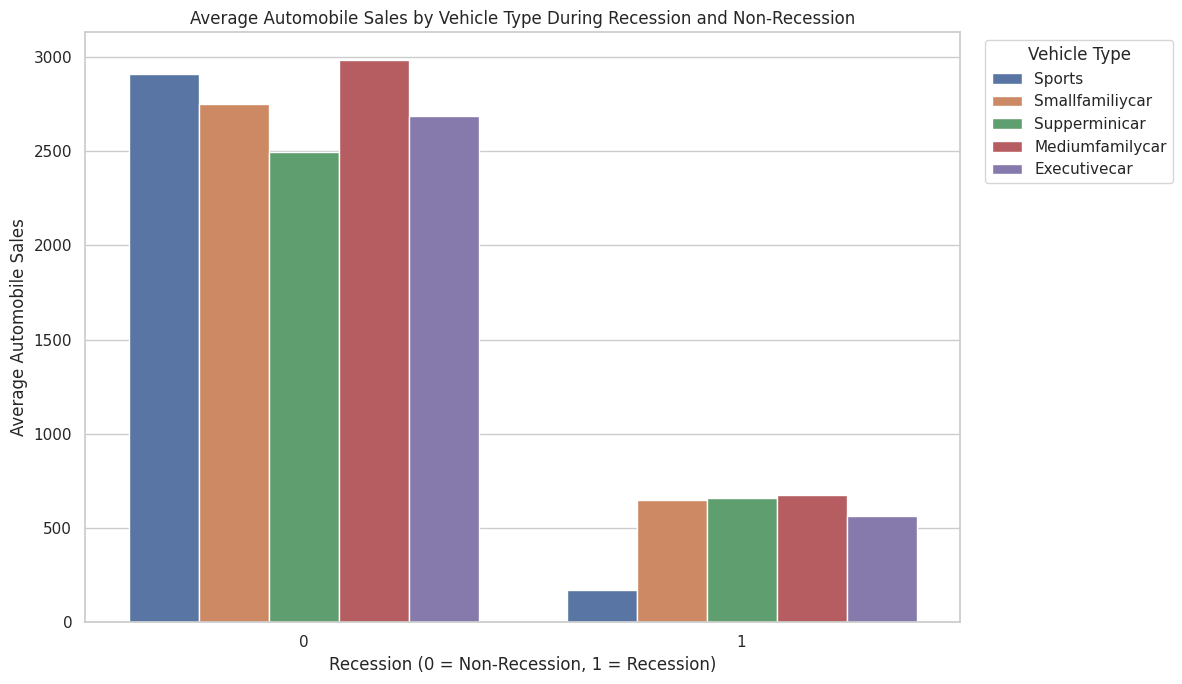

In [4]:
# TASK 1.3
plt.figure(figsize=(12, 7))

sns.barplot(
    data=df,
    x="Recession",
    y="Automobile_Sales",
    hue="Vehicle_Type",
    estimator="mean",
    errorbar=None
)

plt.xlabel("Recession (0 = Non-Recession, 1 = Recession)")
plt.ylabel("Average Automobile Sales")
plt.title("Average Automobile Sales by Vehicle Type During Recession and Non-Recession")
plt.legend(title="Vehicle Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Task 1.4 — Subplots comparing GDP variation during recession and non-recession periods

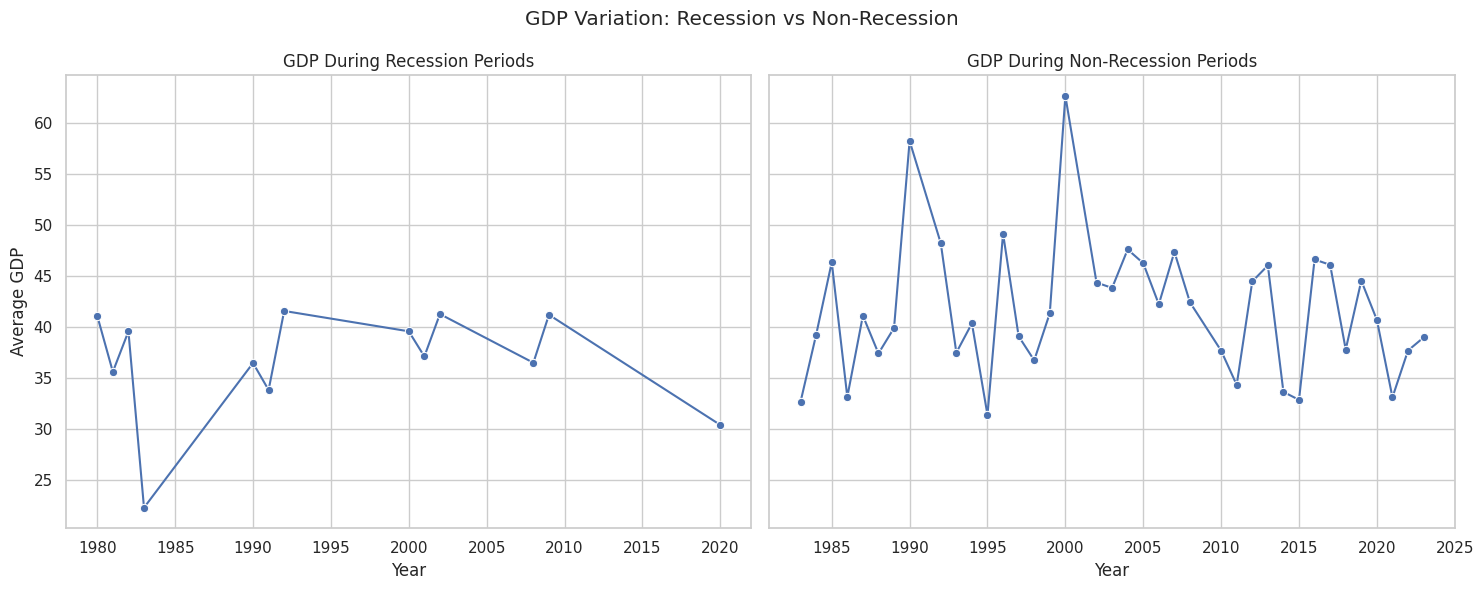

In [5]:
# TASK 1.4
recession_gdp = (
    df[df["Recession"] == 1]
    .groupby("Year")["GDP"]
    .mean()
    .reset_index()
)

non_recession_gdp = (
    df[df["Recession"] == 0]
    .groupby("Year")["GDP"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

sns.lineplot(
    data=recession_gdp,
    x="Year",
    y="GDP",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("GDP During Recession Periods")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average GDP")

sns.lineplot(
    data=non_recession_gdp,
    x="Year",
    y="GDP",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("GDP During Non-Recession Periods")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average GDP")

plt.suptitle("GDP Variation: Recession vs Non-Recession")
plt.tight_layout()
plt.show()

## Task 1.5 — Bubble plot displaying the impact of seasonality on automobile sales

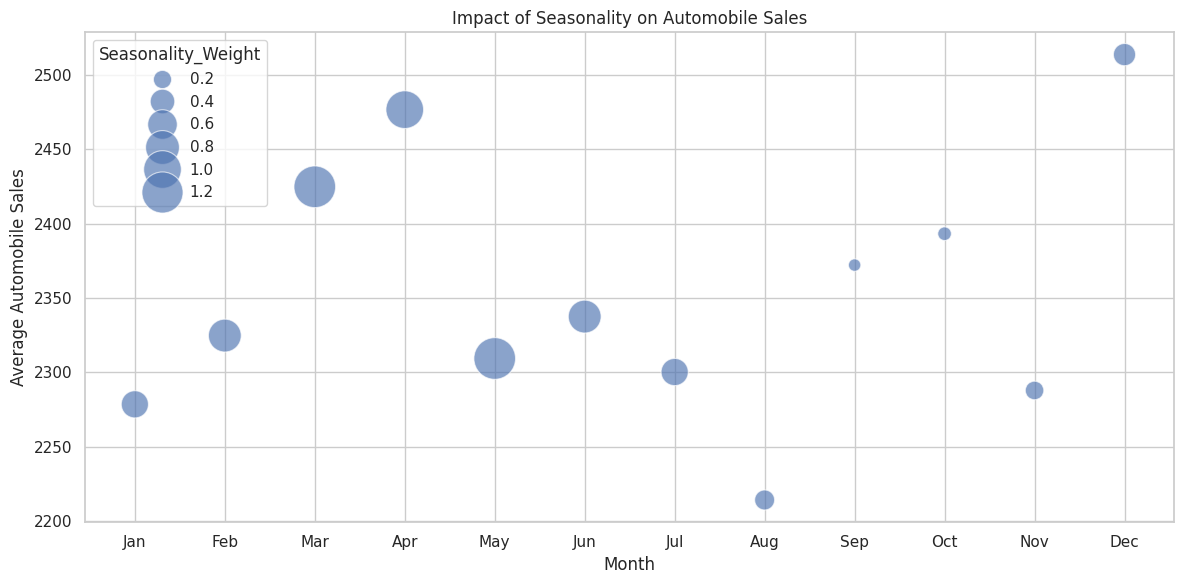

In [6]:
# TASK 1.5
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

seasonality_data = (
    df.groupby("Month", as_index=False)
    .agg(
        Automobile_Sales=("Automobile_Sales", "mean"),
        Seasonality_Weight=("Seasonality_Weight", "mean")
    )
)

# Handle either month names or numeric month values.
if pd.api.types.is_numeric_dtype(seasonality_data["Month"]):
    seasonality_data["Month_Num"] = seasonality_data["Month"]
    seasonality_data["Month_Label"] = seasonality_data["Month_Num"].map(
        dict(enumerate(month_order, start=1))
    )
    seasonality_data = seasonality_data.sort_values("Month_Num")
    x_col = "Month_Label"
else:
    seasonality_data["Month"] = (
        seasonality_data["Month"].astype(str).str[:3]
    )
    seasonality_data["Month"] = pd.Categorical(
        seasonality_data["Month"],
        categories=month_order,
        ordered=True
    )
    seasonality_data = seasonality_data.sort_values("Month")
    x_col = "Month"

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=seasonality_data,
    x=x_col,
    y="Automobile_Sales",
    size="Seasonality_Weight",
    sizes=(80, 900),
    alpha=0.65
)
plt.xlabel("Month")
plt.ylabel("Average Automobile Sales")
plt.title("Impact of Seasonality on Automobile Sales")
plt.tight_layout()
plt.show()

## Task 1.6 — Scatter plot identifying the relationship between average vehicle price and sales during recessions

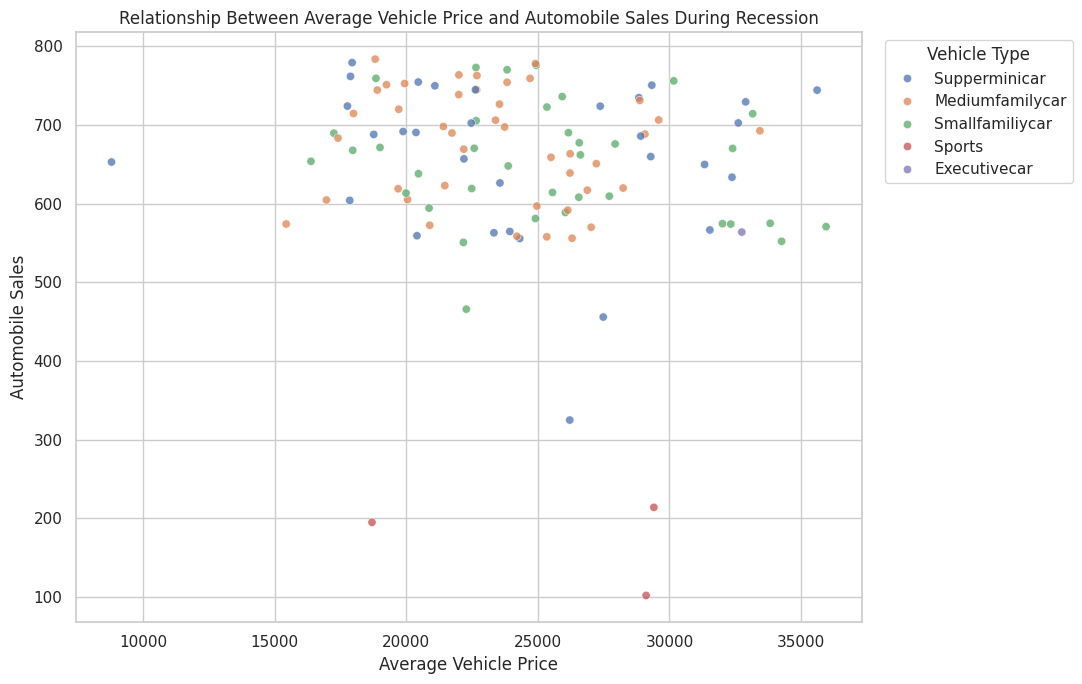

In [7]:
# TASK 1.6
recession_data = df[df["Recession"] == 1].copy()

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=recession_data,
    x="Price",
    y="Automobile_Sales",
    hue="Vehicle_Type",
    alpha=0.75
)

plt.xlabel("Average Vehicle Price")
plt.ylabel("Automobile Sales")
plt.title("Relationship Between Average Vehicle Price and Automobile Sales During Recession")
plt.legend(title="Vehicle Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Task 1.7 — Pie chart showing the portion of advertising expenditure during recession and non-recession periods

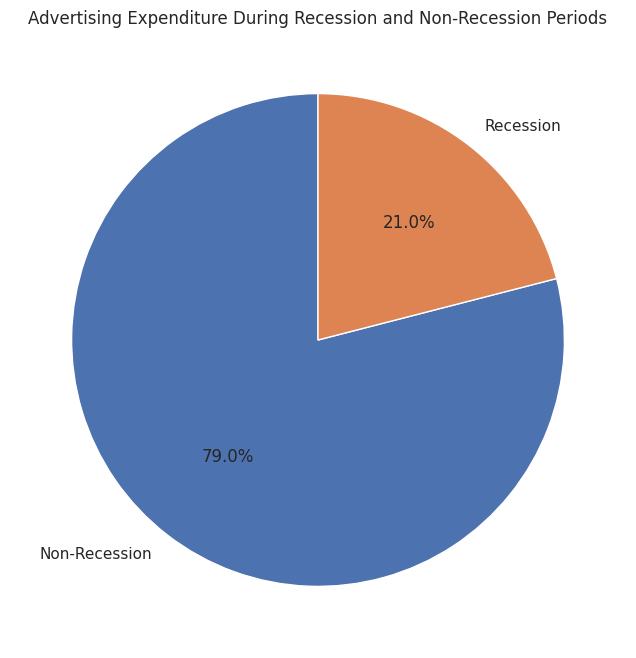

In [8]:
# TASK 1.7
advertising_by_period = df.groupby("Recession")["Advertising_Expenditure"].sum()

labels = ["Non-Recession", "Recession"]
values = [
    advertising_by_period.get(0, 0),
    advertising_by_period.get(1, 0)
]

plt.figure(figsize=(8, 8))
plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Advertising Expenditure During Recession and Non-Recession Periods")
plt.show()

## Task 1.8 — Pie chart showing total advertising expenditure for each vehicle type during recession

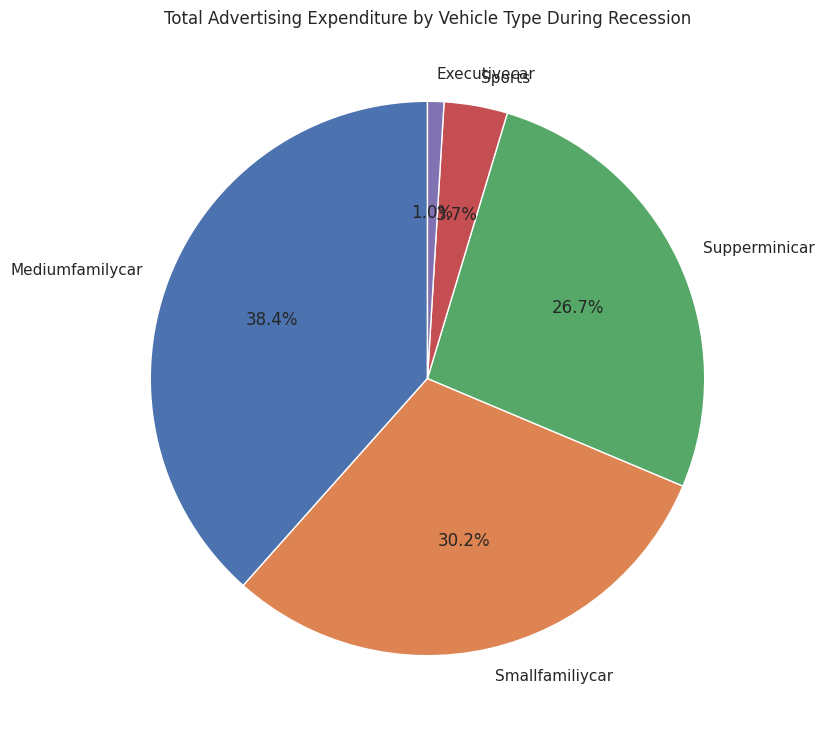

In [9]:
# TASK 1.8
vehicle_advertising_recession = (
    recession_data.groupby("Vehicle_Type")["Advertising_Expenditure"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 9))
plt.pie(
    vehicle_advertising_recession.values,
    labels=vehicle_advertising_recession.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Total Advertising Expenditure by Vehicle Type During Recession")
plt.show()

## Task 1.9 — Line chart analyzing the effect of unemployment rate on vehicle type and automobile sales during recession

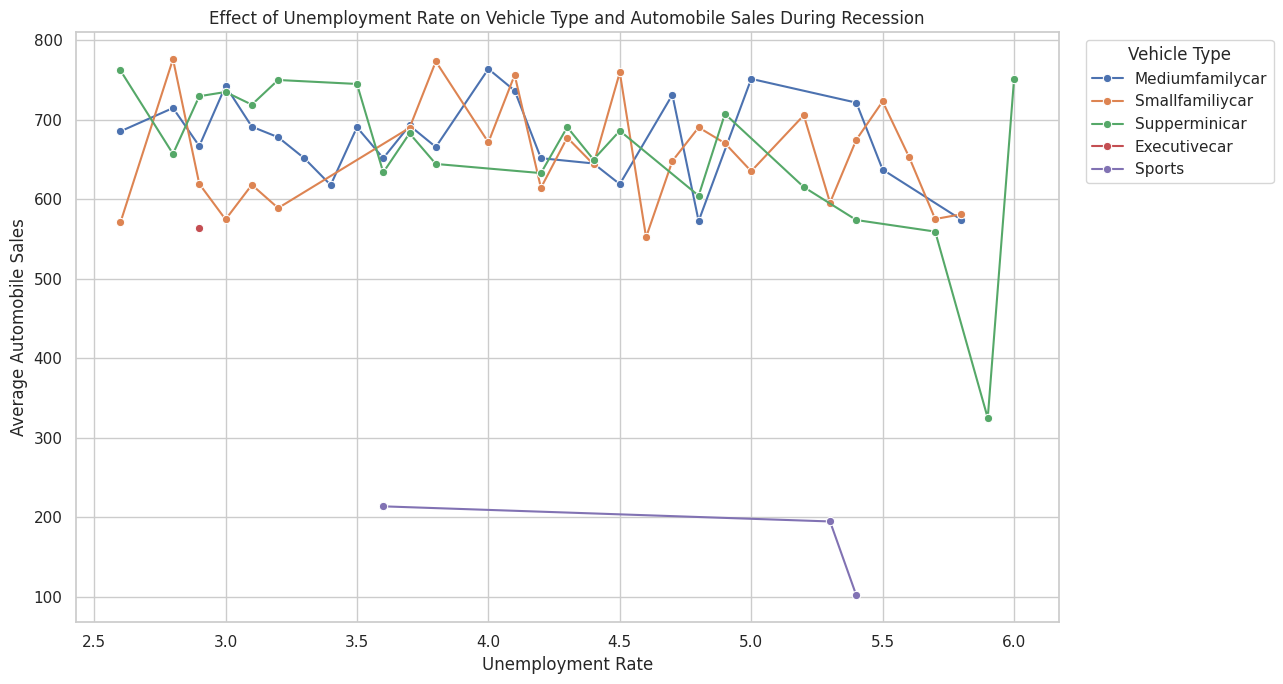

In [10]:
# TASK 1.9
unemployment_sales = (
    recession_data.groupby(
        ["Unemployment_Rate", "Vehicle_Type"],
        as_index=False
    )["Automobile_Sales"]
    .mean()
    .sort_values("Unemployment_Rate")
)

plt.figure(figsize=(13, 7))
sns.lineplot(
    data=unemployment_sales,
    x="Unemployment_Rate",
    y="Automobile_Sales",
    hue="Vehicle_Type",
    marker="o"
)

plt.xlabel("Unemployment Rate")
plt.ylabel("Average Automobile Sales")
plt.title("Effect of Unemployment Rate on Vehicle Type and Automobile Sales During Recession")
plt.legend(title="Vehicle Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Completion Verification

The notebook contains the nine required visualization tasks:

1. Average annual automobile sales
2. Advertising expenditure vs automobile sales during non-recession
3. Vehicle-wise grouped bar chart
4. GDP recession/non-recession subplots
5. Seasonality bubble plot
6. Price vs sales scatter plot during recession
7. Advertising expenditure pie chart by recession status
8. Advertising expenditure pie chart by vehicle type during recession
9. Unemployment rate vs automobile sales by vehicle type during recession

In [11]:
# Final verification cell
required_columns = [
    "Year",
    "Month",
    "Recession",
    "Automobile_Sales",
    "GDP",
    "Seasonality_Weight",
    "Price",
    "Advertising_Expenditure",
    "Vehicle_Type",
    "Unemployment_Rate"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

print("Required columns missing:", missing_columns)
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

if not missing_columns:
    print("All required columns for Tasks 1.1–1.9 are present.")
    print("Notebook contains all nine required visualization tasks.")
else:
    print("Please check the dataset before submission.")

Required columns missing: []
Number of rows: 528
Number of columns: 16
All required columns for Tasks 1.1–1.9 are present.
Notebook contains all nine required visualization tasks.
